Saving fashion_productss.csv to fashion_productss.csv
File uploaded successfully: fashion_productss.csv

First 5 rows:
   User ID  Product ID Product Name   Brand         Category  Price    Rating  \
0       19           1        Dress  Adidas    Men's Fashion     40  1.043159   
1       97           2        Shoes     H&M  Women's Fashion     82  4.026416   
2       25           3        Dress  Adidas  Women's Fashion     44  3.337938   
3       57           4        Shoes    Zara    Men's Fashion     23  1.049523   
4       79           5      T-shirt  Adidas    Men's Fashion     79  4.302773   

    Color Size  
0   Black   XL  
1   Black    L  
2  Yellow   XL  
3   White    S  
4   Black    M  

Dataset Shape:
(1000, 9)

Column Names:
['User ID', 'Product ID', 'Product Name', 'Brand', 'Category', 'Price', 'Rating', 'Color', 'Size']

Data Types:
User ID           int64
Product ID        int64
Product Name     object
Brand            object
Category         object
Price             i

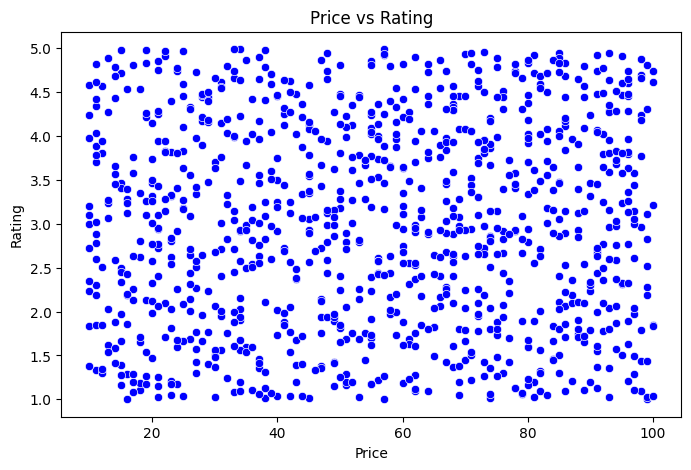

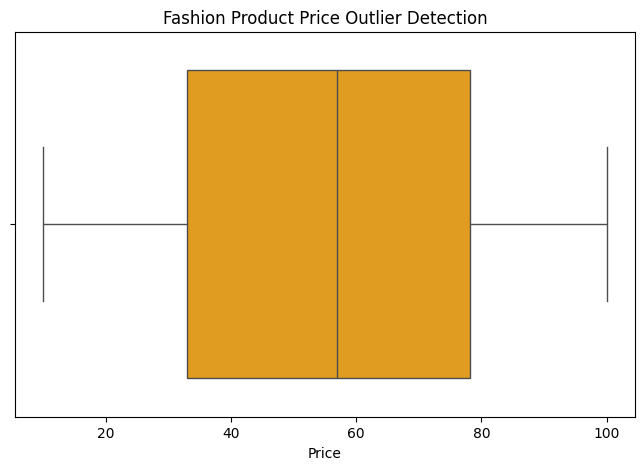

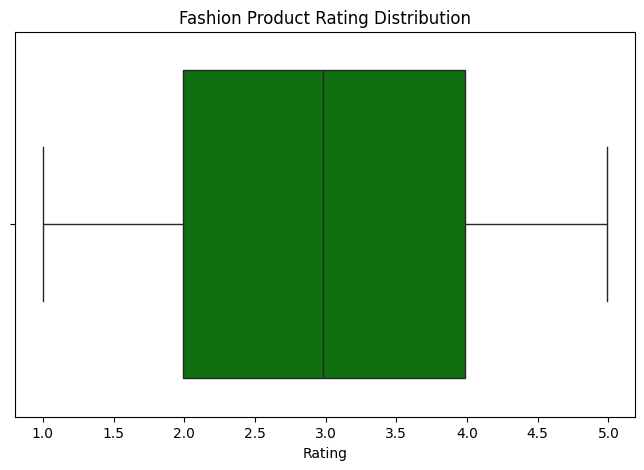


Correlation Matrix:
             User ID  Product ID     Price    Rating
User ID     1.000000   -0.021075  0.003363  0.044837
Product ID -0.021075    1.000000  0.034602  0.033896
Price       0.003363    0.034602  1.000000  0.033927
Rating      0.044837    0.033896  0.033927  1.000000


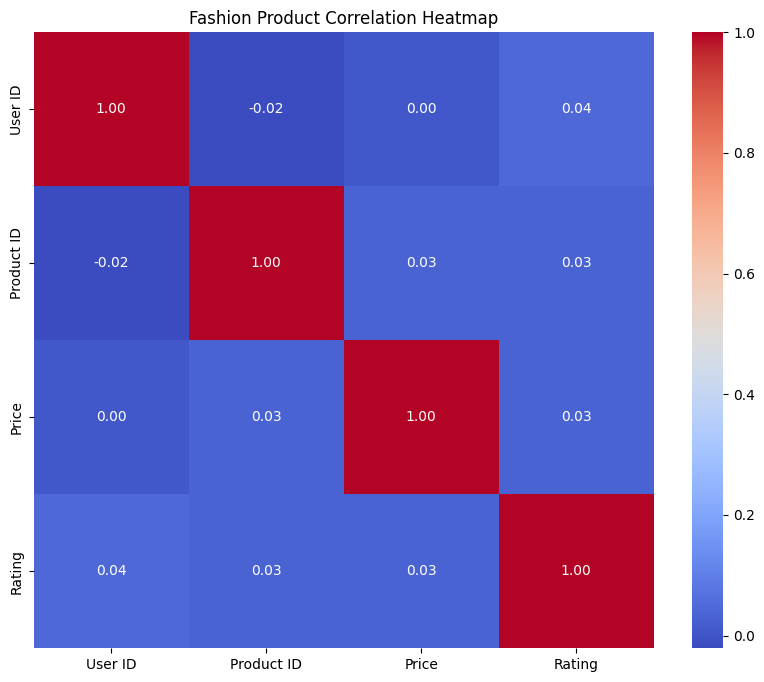

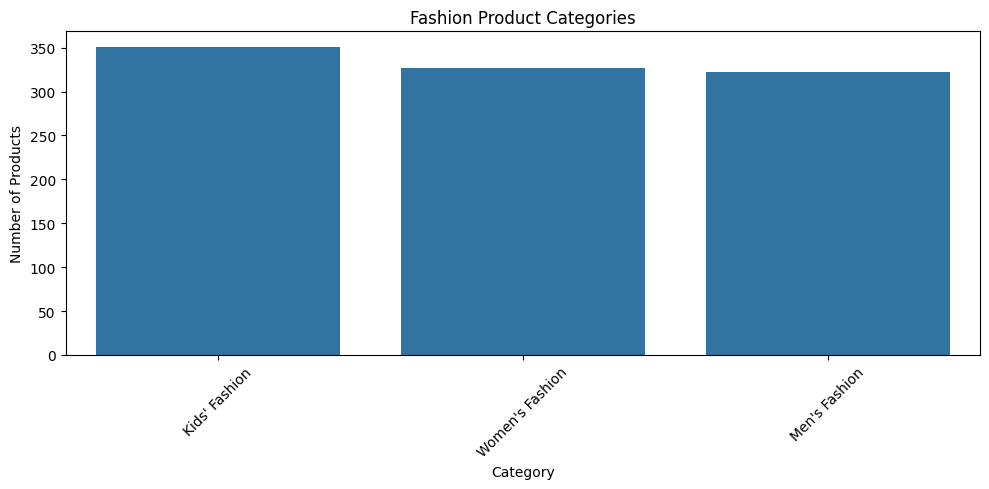

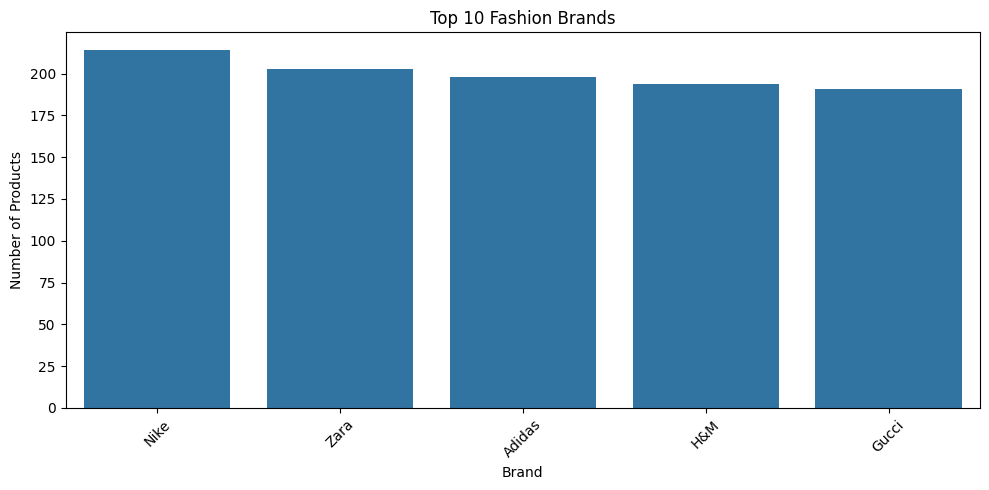

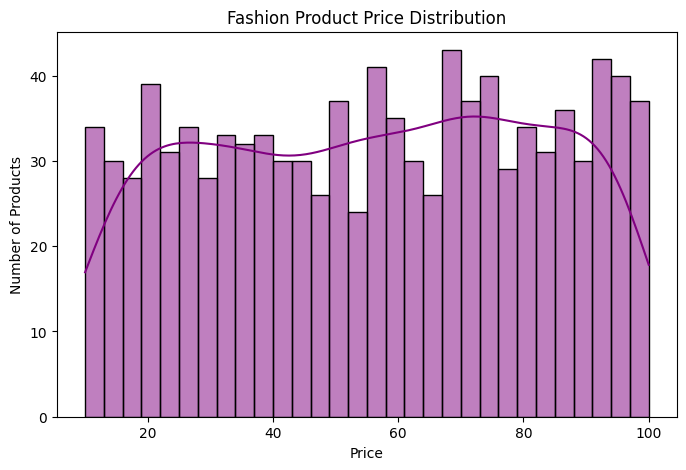

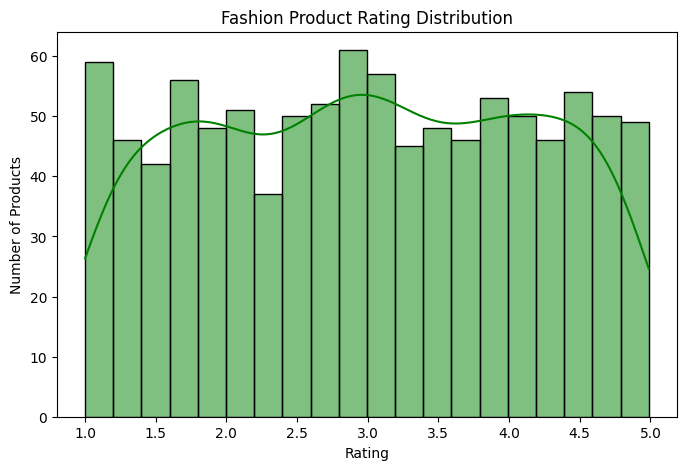

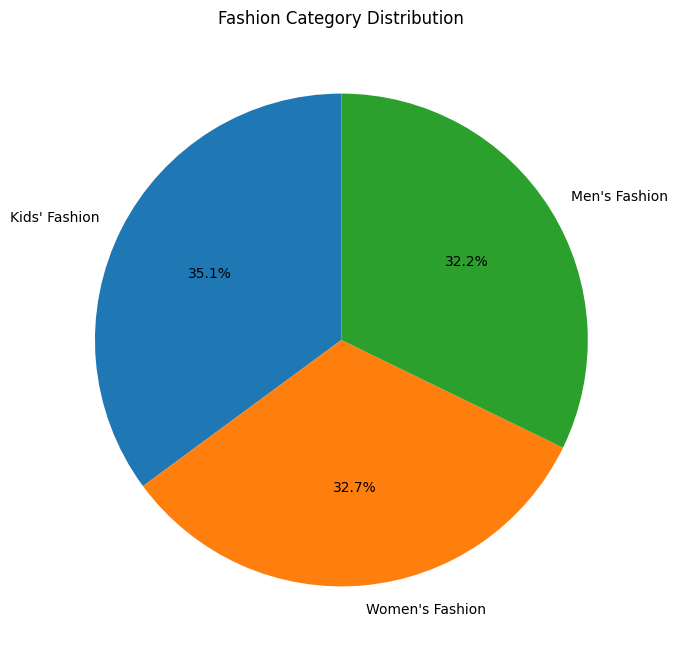

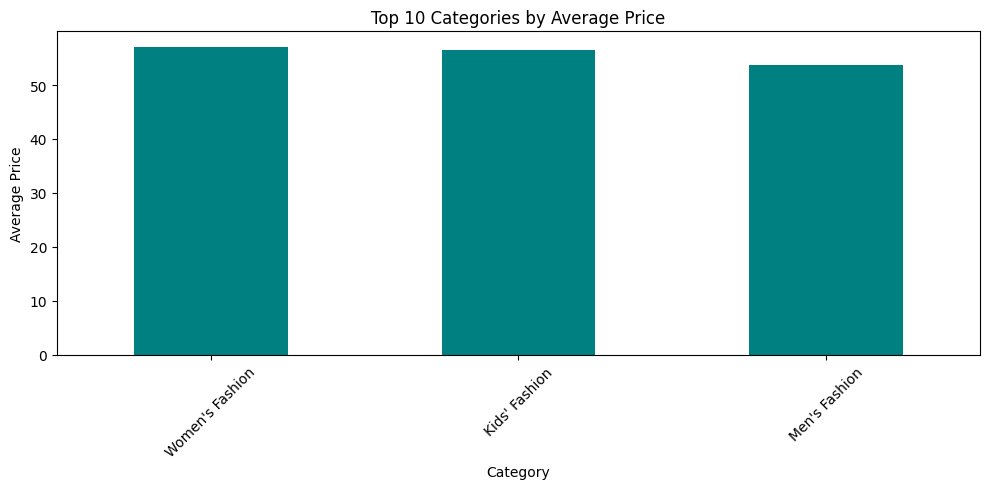

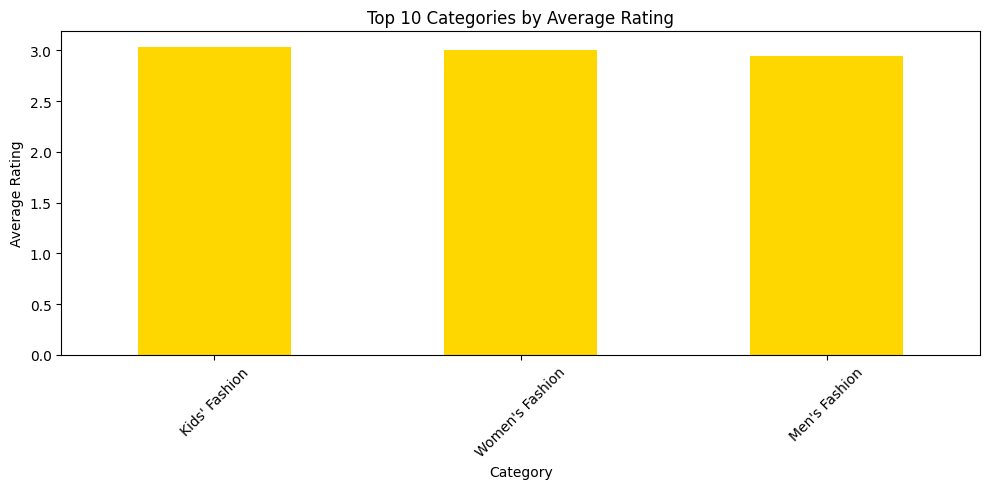

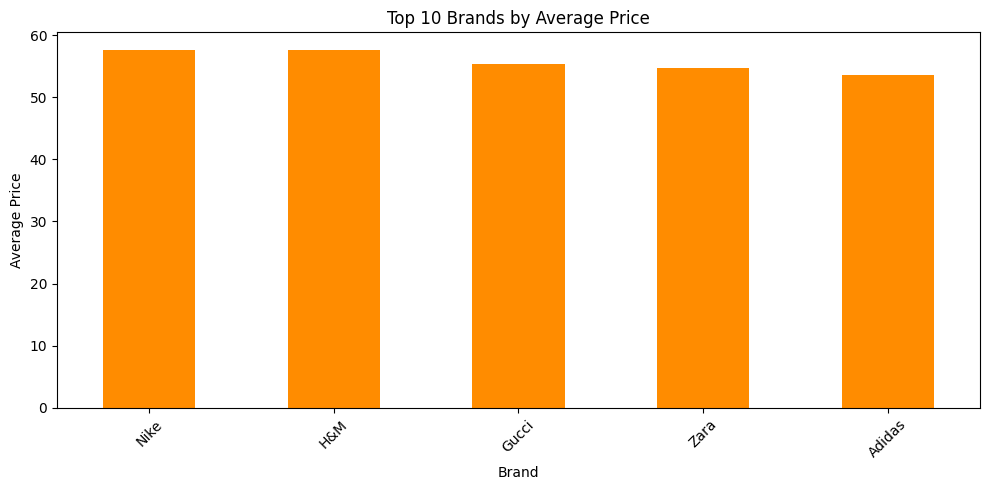

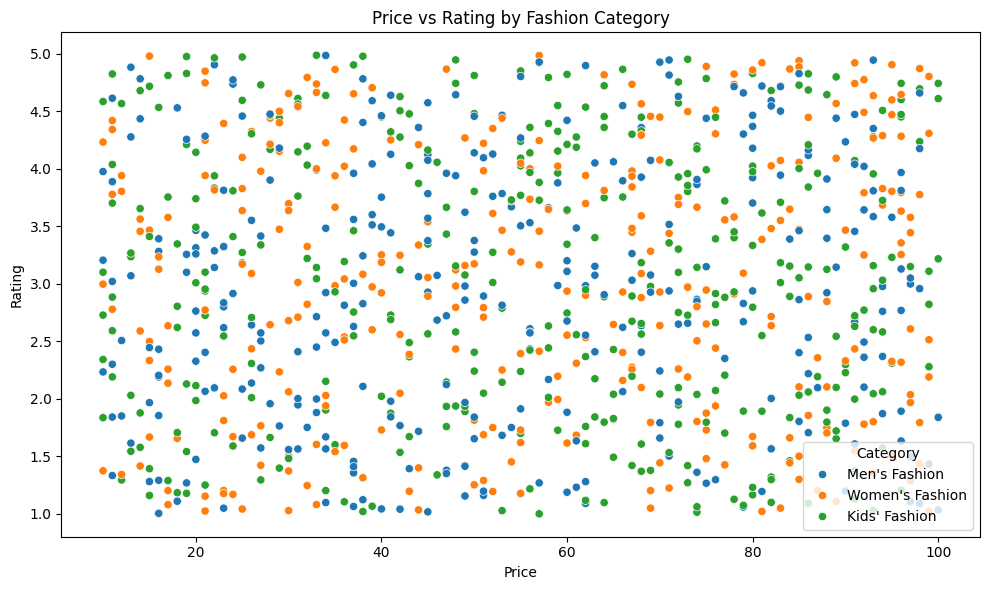

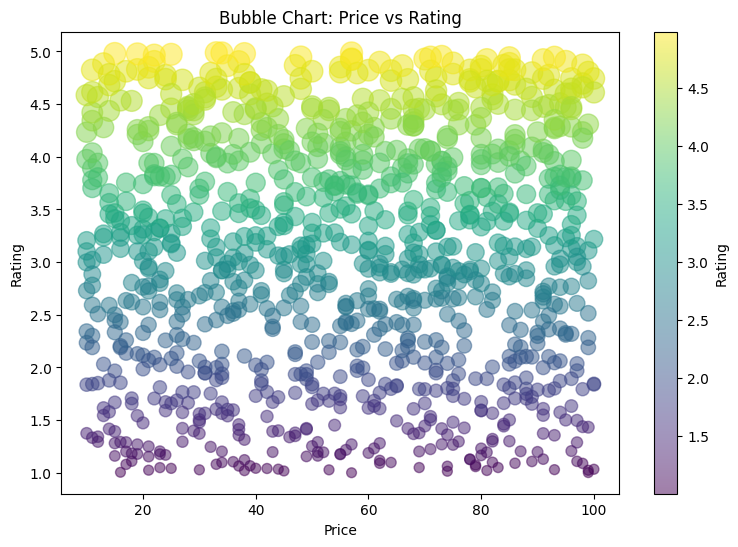

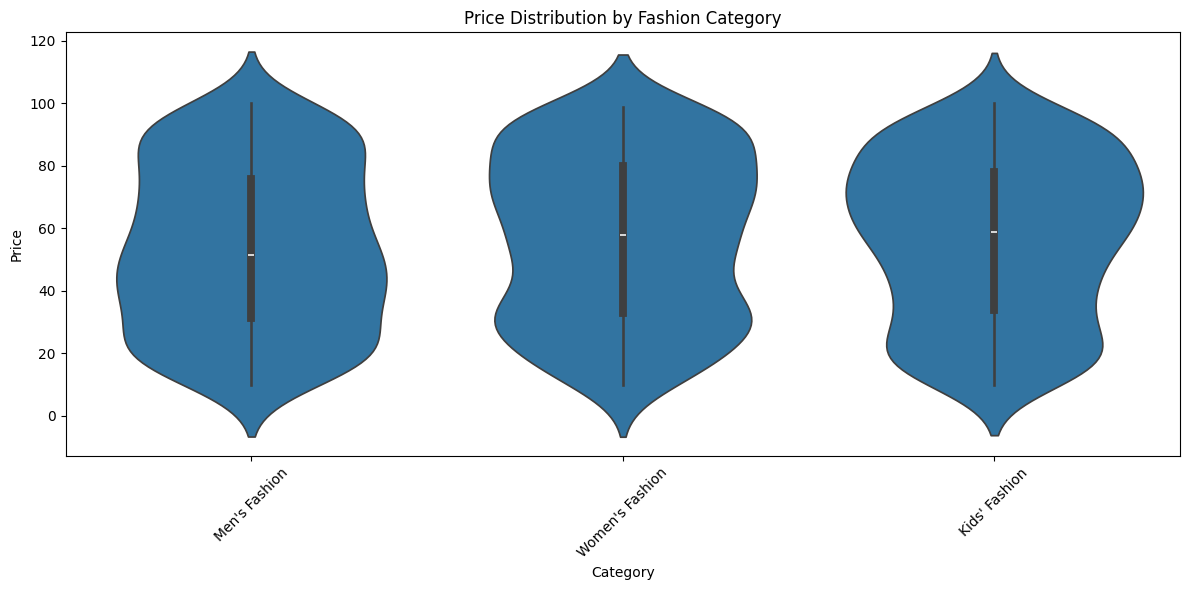

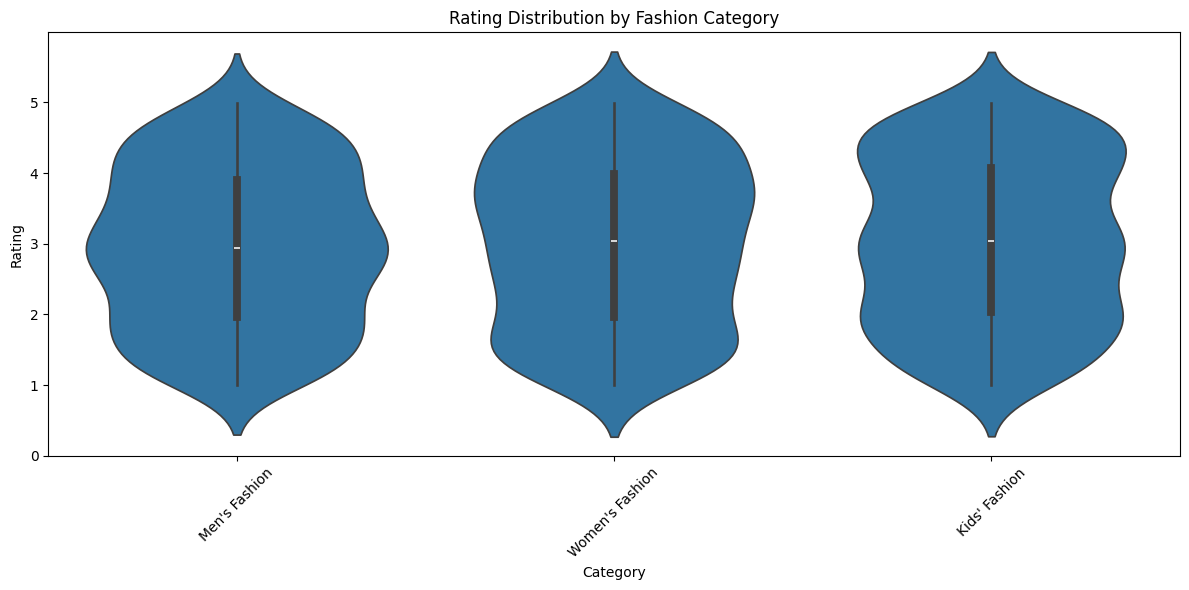

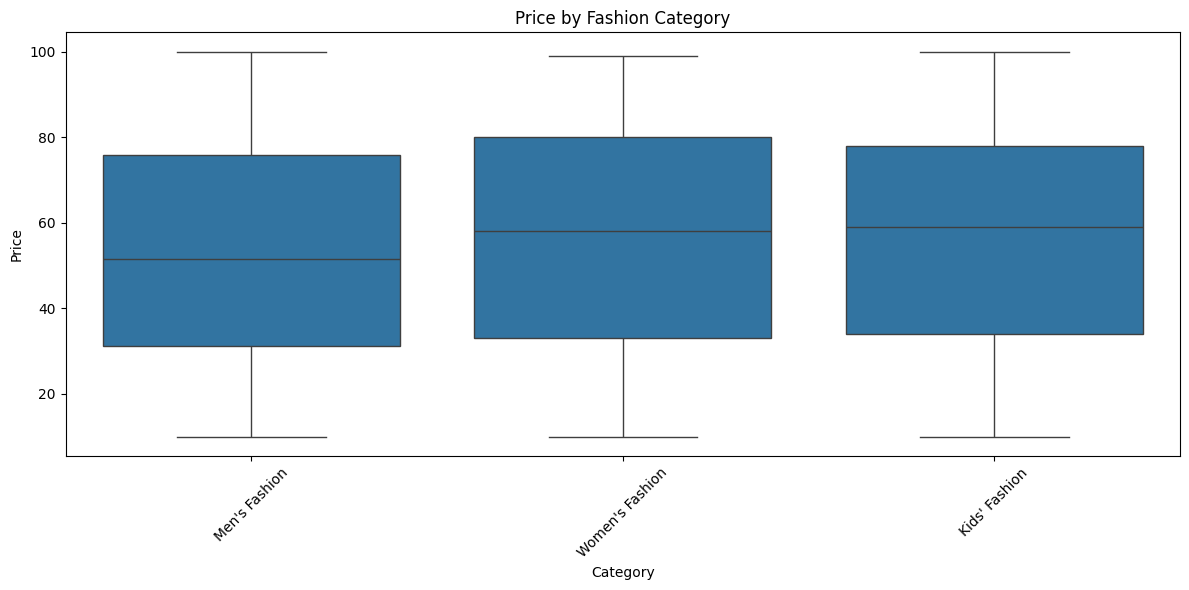

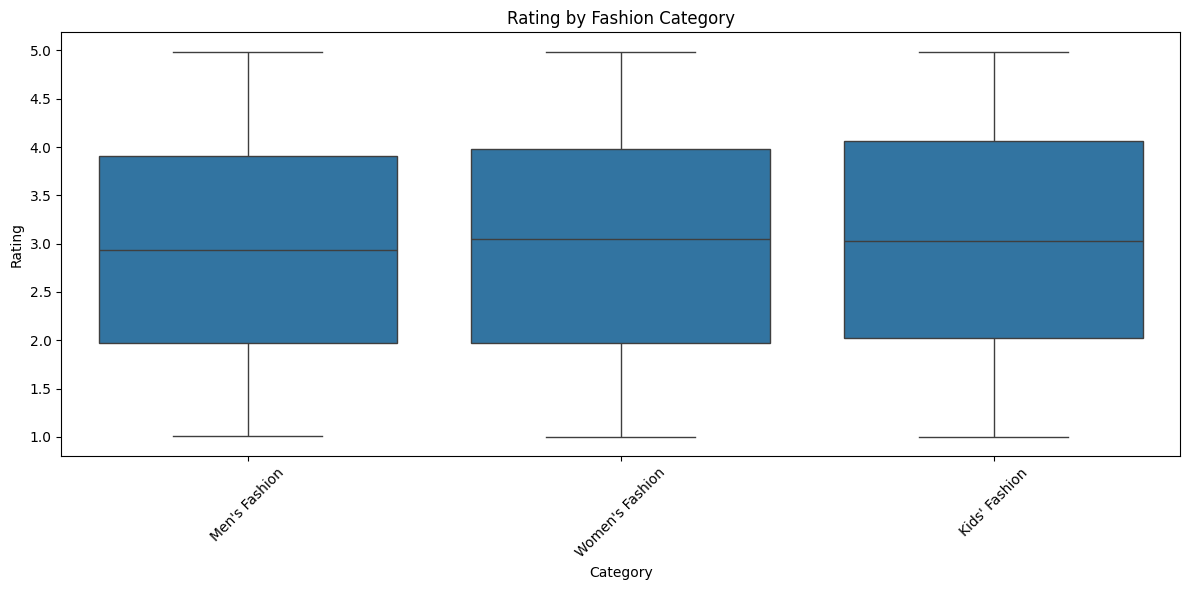

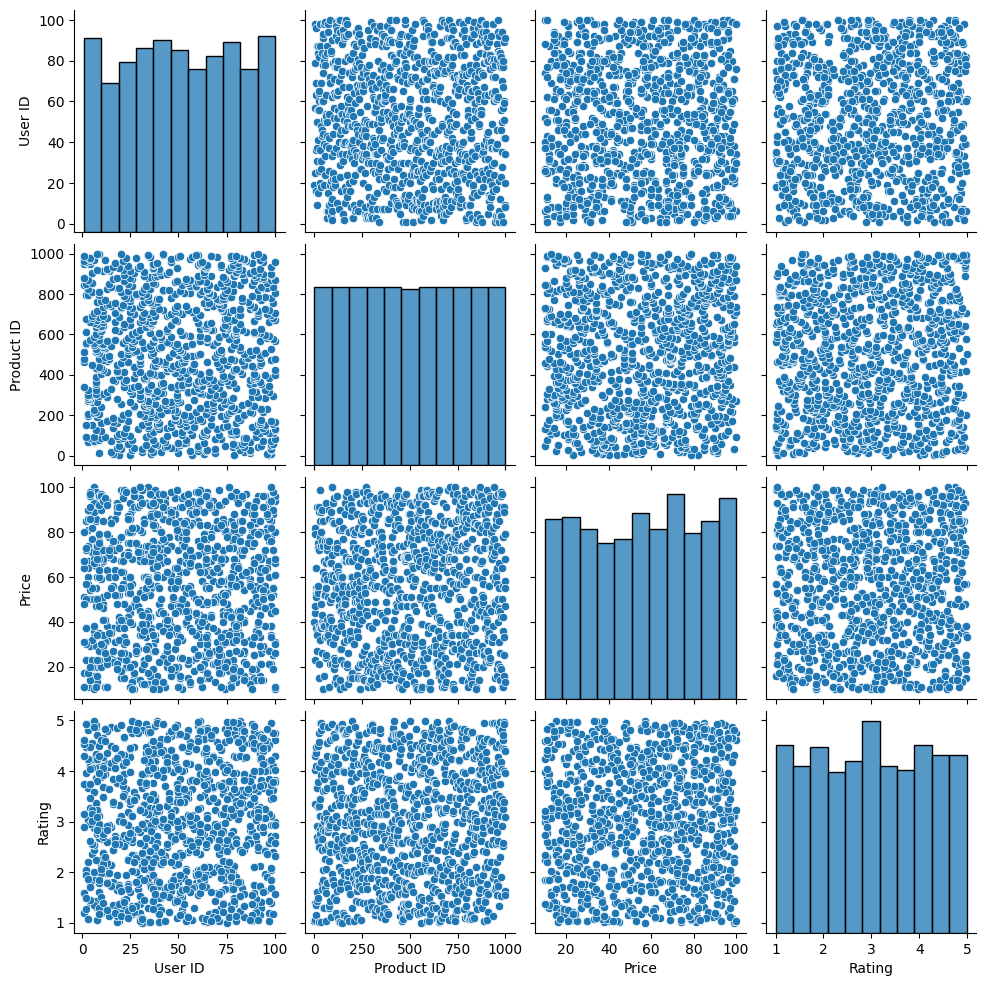



       FASHION PRODUCT ANALYSIS COMPLETE

Dataset Rows : 1000
Dataset Columns : 9

Numeric Columns:
['User ID', 'Product ID', 'Price', 'Rating']

Categorical Columns:
['Product Name', 'Brand', 'Category', 'Color', 'Size']

Analysis completed successfully!


In [1]:
# ============================================================
# FASHION PRODUCT ANALYSIS
# DATA VISUALIZATION AND EXPLORATORY ANALYSIS
# ============================================================


# ============================================================
# IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns


# ============================================================
# UPLOAD DATASET
# ============================================================

from google.colab import files

uploaded = files.upload()

# Automatically get uploaded filename

filename = list(uploaded.keys())[0]

df = pd.read_csv(filename)

print("File uploaded successfully:", filename)

print("\nFirst 5 rows:")
print(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())


# ============================================================
# DATA TYPES
# ============================================================

print("\nData Types:")

print(df.dtypes)


# ============================================================
# DESCRIPTIVE STATISTICS
# ============================================================

print("\nDescriptive Statistics:")

print(df.describe())


# ============================================================
# MISSING VALUES
# ============================================================

print("\nMissing Values:")

print(df.isnull().sum())


# ============================================================
# DUPLICATE ROWS
# ============================================================

print("\nDuplicate Rows:")

print(df.duplicated().sum())


# ============================================================
# FIND NUMERIC COLUMNS
# ============================================================

numeric_cols = df.select_dtypes(
    include=np.number
).columns.tolist()

print("\nNumeric Columns:")

print(numeric_cols)


# ============================================================
# FIND CATEGORICAL COLUMNS
# ============================================================

categorical_cols = df.select_dtypes(
    include="object"
).columns.tolist()

print("\nCategorical Columns:")

print(categorical_cols)


# ============================================================
# PRICE VS RATING SCATTER PLOT
# ============================================================

if "Price" in df.columns and "Rating" in df.columns:

    plt.figure(figsize=(8,5))

    sns.scatterplot(
        data=df,
        x="Price",
        y="Rating",
        color="blue"
    )

    plt.title("Price vs Rating")

    plt.xlabel("Price")

    plt.ylabel("Rating")

    plt.show()


# ============================================================
# PRICE OUTLIER DETECTION
# ============================================================

if "Price" in df.columns:

    plt.figure(figsize=(8,5))

    sns.boxplot(
        x=df["Price"],
        color="orange"
    )

    plt.title("Fashion Product Price Outlier Detection")

    plt.xlabel("Price")

    plt.show()


# ============================================================
# RATING OUTLIER DETECTION
# ============================================================

if "Rating" in df.columns:

    plt.figure(figsize=(8,5))

    sns.boxplot(
        x=df["Rating"],
        color="green"
    )

    plt.title("Fashion Product Rating Distribution")

    plt.xlabel("Rating")

    plt.show()


# ============================================================
# CORRELATION HEATMAP
# ============================================================

if len(numeric_cols) >= 2:

    corr = df[numeric_cols].corr()

    print("\nCorrelation Matrix:")

    print(corr)

    plt.figure(figsize=(10,8))

    sns.heatmap(
        corr,
        annot=True,
        cmap="coolwarm",
        fmt=".2f"
    )

    plt.title(
        "Fashion Product Correlation Heatmap"
    )

    plt.show()


# ============================================================
# CATEGORY COUNT
# ============================================================

if "Category" in df.columns:

    plt.figure(figsize=(10,5))

    sns.countplot(
        data=df,
        x="Category",
        order=df["Category"].value_counts().index
    )

    plt.xticks(rotation=45)

    plt.title(
        "Fashion Product Categories"
    )

    plt.xlabel("Category")

    plt.ylabel("Number of Products")

    plt.tight_layout()

    plt.show()


# ============================================================
# BRAND COUNT
# ============================================================

if "Brand" in df.columns:

    plt.figure(figsize=(10,5))

    top_brands = (
        df["Brand"]
        .value_counts()
        .head(10)
        .index
    )

    sns.countplot(
        data=df[
            df["Brand"].isin(top_brands)
        ],
        x="Brand",
        order=top_brands
    )

    plt.xticks(rotation=45)

    plt.title(
        "Top 10 Fashion Brands"
    )

    plt.xlabel("Brand")

    plt.ylabel("Number of Products")

    plt.tight_layout()

    plt.show()


# ============================================================
# PRICE DISTRIBUTION
# ============================================================

if "Price" in df.columns:

    plt.figure(figsize=(8,5))

    sns.histplot(
        df["Price"],
        bins=30,
        kde=True,
        color="purple"
    )

    plt.title(
        "Fashion Product Price Distribution"
    )

    plt.xlabel("Price")

    plt.ylabel("Number of Products")

    plt.show()


# ============================================================
# RATING DISTRIBUTION
# ============================================================

if "Rating" in df.columns:

    plt.figure(figsize=(8,5))

    sns.histplot(
        df["Rating"],
        bins=20,
        kde=True,
        color="green"
    )

    plt.title(
        "Fashion Product Rating Distribution"
    )

    plt.xlabel("Rating")

    plt.ylabel("Number of Products")

    plt.show()


# ============================================================
# CATEGORY DISTRIBUTION - PIE CHART
# ============================================================

if "Category" in df.columns:

    category = df["Category"].value_counts()

    plt.figure(figsize=(8,8))

    plt.pie(
        category,
        labels=category.index,
        autopct="%1.1f%%",
        startangle=90
    )

    plt.title(
        "Fashion Category Distribution"
    )

    plt.show()


# ============================================================
# AVERAGE PRICE BY CATEGORY
# ============================================================

if (
    "Category" in df.columns
    and "Price" in df.columns
):

    category_price = (
        df.groupby("Category")["Price"]
        .mean()
        .sort_values(ascending=False)
        .head(10)
    )

    plt.figure(figsize=(10,5))

    category_price.plot(
        kind="bar",
        color="teal"
    )

    plt.title(
        "Top 10 Categories by Average Price"
    )

    plt.xlabel("Category")

    plt.ylabel("Average Price")

    plt.xticks(rotation=45)

    plt.tight_layout()

    plt.show()


# ============================================================
# AVERAGE RATING BY CATEGORY
# ============================================================

if (
    "Category" in df.columns
    and "Rating" in df.columns
):

    category_rating = (
        df.groupby("Category")["Rating"]
        .mean()
        .sort_values(ascending=False)
        .head(10)
    )

    plt.figure(figsize=(10,5))

    category_rating.plot(
        kind="bar",
        color="gold"
    )

    plt.title(
        "Top 10 Categories by Average Rating"
    )

    plt.xlabel("Category")

    plt.ylabel("Average Rating")

    plt.xticks(rotation=45)

    plt.tight_layout()

    plt.show()


# ============================================================
# TOP 10 BRANDS BY AVERAGE PRICE
# ============================================================

if (
    "Brand" in df.columns
    and "Price" in df.columns
):

    brand_price = (
        df.groupby("Brand")["Price"]
        .mean()
        .sort_values(ascending=False)
        .head(10)
    )

    plt.figure(figsize=(10,5))

    brand_price.plot(
        kind="bar",
        color="darkorange"
    )

    plt.title(
        "Top 10 Brands by Average Price"
    )

    plt.xlabel("Brand")

    plt.ylabel("Average Price")

    plt.xticks(rotation=45)

    plt.tight_layout()

    plt.show()


# ============================================================
# PRICE VS RATING BY CATEGORY
# ============================================================

if (
    "Price" in df.columns
    and "Rating" in df.columns
    and "Category" in df.columns
):

    plt.figure(figsize=(10,6))

    sns.scatterplot(
        data=df,
        x="Price",
        y="Rating",
        hue="Category"
    )

    plt.title(
        "Price vs Rating by Fashion Category"
    )

    plt.xlabel("Price")

    plt.ylabel("Rating")

    plt.tight_layout()

    plt.show()


# ============================================================
# PRICE VS RATING - BUBBLE CHART
# ============================================================

if (
    "Price" in df.columns
    and "Rating" in df.columns
):

    plt.figure(figsize=(9,6))

    # Create bubble sizes from Rating

    bubble_size = (
        df["Rating"].fillna(
            df["Rating"].median()
        ) * 50
    )

    plt.scatter(
        df["Price"],
        df["Rating"],
        s=bubble_size,
        alpha=0.5,
        c=df["Rating"],
        cmap="viridis"
    )

    plt.colorbar(
        label="Rating"
    )

    plt.xlabel("Price")

    plt.ylabel("Rating")

    plt.title(
        "Bubble Chart: Price vs Rating"
    )

    plt.show()


# ============================================================
# CATEGORY VS PRICE - VIOLIN PLOT
# ============================================================

if (
    "Category" in df.columns
    and "Price" in df.columns
):

    plt.figure(figsize=(12,6))

    sns.violinplot(
        data=df,
        x="Category",
        y="Price"
    )

    plt.xticks(rotation=45)

    plt.title(
        "Price Distribution by Fashion Category"
    )

    plt.xlabel("Category")

    plt.ylabel("Price")

    plt.tight_layout()

    plt.show()


# ============================================================
# CATEGORY VS RATING - VIOLIN PLOT
# ============================================================

if (
    "Category" in df.columns
    and "Rating" in df.columns
):

    plt.figure(figsize=(12,6))

    sns.violinplot(
        data=df,
        x="Category",
        y="Rating"
    )

    plt.xticks(rotation=45)

    plt.title(
        "Rating Distribution by Fashion Category"
    )

    plt.xlabel("Category")

    plt.ylabel("Rating")

    plt.tight_layout()

    plt.show()


# ============================================================
# CATEGORY VS PRICE - BOX PLOT
# ============================================================

if (
    "Category" in df.columns
    and "Price" in df.columns
):

    plt.figure(figsize=(12,6))

    sns.boxplot(
        data=df,
        x="Category",
        y="Price"
    )

    plt.xticks(rotation=45)

    plt.title(
        "Price by Fashion Category"
    )

    plt.xlabel("Category")

    plt.ylabel("Price")

    plt.tight_layout()

    plt.show()


# ============================================================
# CATEGORY VS RATING - BOX PLOT
# ============================================================

if (
    "Category" in df.columns
    and "Rating" in df.columns
):

    plt.figure(figsize=(12,6))

    sns.boxplot(
        data=df,
        x="Category",
        y="Rating"
    )

    plt.xticks(rotation=45)

    plt.title(
        "Rating by Fashion Category"
    )

    plt.xlabel("Category")

    plt.ylabel("Rating")

    plt.tight_layout()

    plt.show()


# ============================================================
# PAIRPLOT
# ============================================================

# Select up to 5 numeric columns

pair_columns = numeric_cols[:5]

if len(pair_columns) >= 2:

    sns.pairplot(
        df[pair_columns].dropna()
    )

    plt.show()


# ============================================================
# FINAL SUMMARY
# ============================================================

print("\n")
print("==============================================")
print("       FASHION PRODUCT ANALYSIS COMPLETE")
print("==============================================")

print(
    "\nDataset Rows :",
    df.shape[0]
)

print(
    "Dataset Columns :",
    df.shape[1]
)

print(
    "\nNumeric Columns:"
)

print(numeric_cols)

print(
    "\nCategorical Columns:"
)

print(categorical_cols)

print(
    "\nAnalysis completed successfully!"
)
